In [1]:
%reload_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from solarrpy import seasonalClearsky
from solarrpy import seasonalModel
from solarrpy import seasonalSolarFunctions

In [2]:
"""
import cdsapi

dataset = "cams-solar-radiation-timeseries"
request = {
    "sky_type": "observed_cloud",
    "location": {"longitude": 11.3426, "latitude": 44.4949},
    "altitude": ["71"],
    "date": ["2005-01-01/2026-03-31"],
    "time_step": "1day",
    "time_reference": "true_solar_time",
    "data_format": "csv"
}

client = cdsapi.Client()
client.retrieve(dataset, request).download()
"""

'\nimport cdsapi\n\ndataset = "cams-solar-radiation-timeseries"\nrequest = {\n    "sky_type": "observed_cloud",\n    "location": {"longitude": 11.3426, "latitude": 44.4949},\n    "altitude": ["71"],\n    "date": ["2005-01-01/2026-03-31"],\n    "time_step": "1day",\n    "time_reference": "true_solar_time",\n    "data_format": "csv"\n}\n\nclient = cdsapi.Client()\nclient.retrieve(dataset, request).download()\n'

In [ ]:
# 1. Load the csv file
df = pd.read_csv('../data/CAMS_data/CAMS_data_Bologna.csv')
#df = pd.read_csv('../data/Bologna/data.csv')

# 2. Construct the `spec` dictionary expected by the modeling script
spec = {
    'data': df,
    # Adjust this latitude to match your dataset's exact location (44.4949 is Bologna)
    # Adjust this altitude to match your dataset's exact location (71 is Bologna)
    'coords': {'lat': 44.4949, 'alt': 71}, 
    # Ensure this matches the exact column name for GHI in your DataFrame
    'target': 'GHI'
}

print("Data loaded successfully!")
print(spec['data'].head())

Data loaded successfully!
         date  n  Year  Month  Day       GHI  clearsky        H0
0  2005-01-01  1  2005      1    1  2.119092  2.121743  3.092413
1  2005-01-02  2  2005      1    2  1.989455  2.034250  3.106099
2  2005-01-03  3  2005      1    3  1.916320  1.933749  3.121117
3  2005-01-04  4  2005      1    4  2.046598  2.123760  3.137465
4  2005-01-05  5  2005      1    5  1.975995  2.097890  3.155143


----------------------- seasonalClearsky ----------------------- 
 - Order: 1
 - Period: 365
- External regressors: 1 (H0) 
- Version: 1.0.1
--------------------------------------------------------------
                                         coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------------------
Intercept                             -1.0302      0.316     -3.255      0.001      -1.651      -0.410
H0                                     0.8320      0.042     19.598      0.000       0.749       0.915
I(np.sin(2 * np.pi / 365 * n * 1))     0.0098      0.031      0.311      0.756      -0.052       0.072
I(np.cos(2 * np.pi / 365 * n * 1))     0.4478      0.181      2.473      0.013       0.093       0.803


/var/folders/pj/s8thlv2s5ls_9mngg8y0qvq00000gn/T/ipykernel_94130/2843578132.py:62: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  df_plot = data[mask]


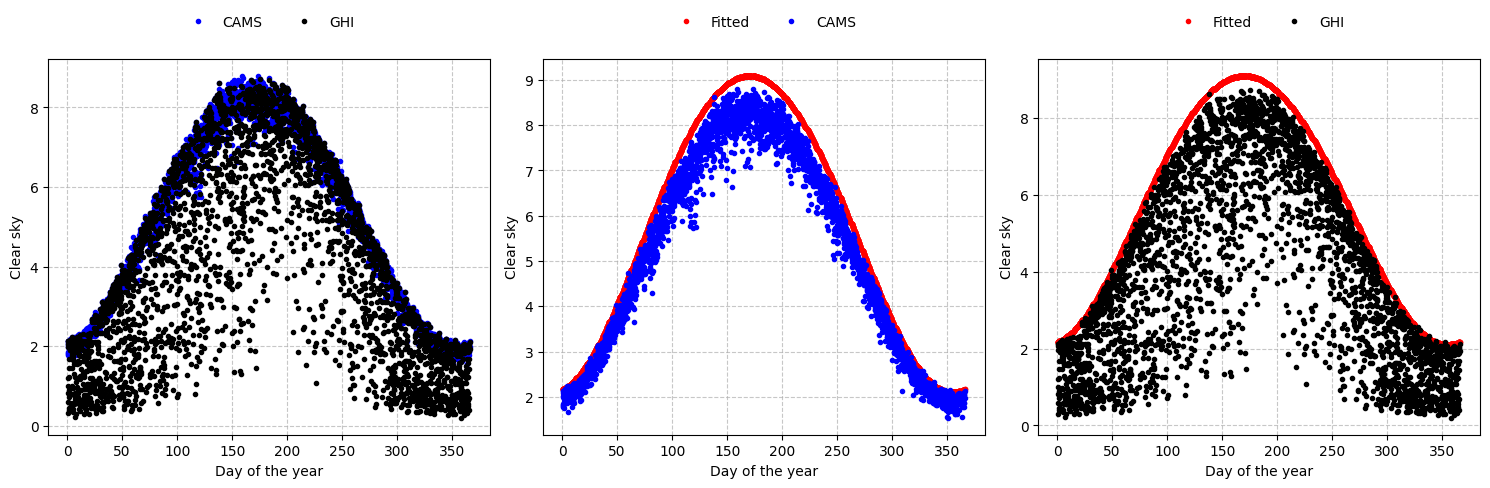

---------------   Test clearskyModel_control and clearskyModel_fit ---------------
Check if the number of outliers imputed is below 10...(10) Passed!

Check if the parameter delta is inside lower (0) and upper (3)...(1.1046) Passed!

Check if the number of parameters is equal to 4...(4) Passed!

Numerical Differential: 
0    0.046892
dtype: float64
Analytical Differential: 
0    0.046872
dtype: float64


In [4]:
# ----------------------------------------------------------------------------
# NOTE: This script assumes the existence of the previously translated classes/functions:
# SeasonalClearsky, control_seasonalClearsky, clearsky_outliers
# 
# It also assumes a pre-existing `spec` object/dictionary that contains the dataset.
# For example:
# spec = {
#     'data': pd.DataFrame({'GHI': [...], 'date': [...], 'clearsky': [...], 'n': [...]}),
#     'coords': {'lat': 45.0},
#     'target': 'GHI'
# }
# ----------------------------------------------------------------------------

# ==========================================
# Inputs
# ==========================================

# Control parameters
control = seasonalClearsky.control_seasonalClearsky(
    order=1, order_H0=1, period=365, 
    include_intercept=True, include_trend=False,
    delta0=1.4, lower=0, upper=3, by=0.001, ntol=10, quiet=False
)

# Extracting from mock `spec` object
data_all = spec['data'].copy()
data_all['date'] = pd.to_datetime(data_all['date'])
lat = spec['coords']['lat']
alt = spec['coords']['alt']
target_col = spec['target']

for year_i in range(2013, 2014):
    mask = data_all['date'].dt.year <= year_i
    data = data_all.loc[mask].copy()

    #print(f"\nRunning model with data up to {year_i}-12-31 ({len(data)} rows)")

    GHI = data['GHI']
    date = data['date']
    clearsky = data['clearsky']
    H0 = data['H0']

    # ==========================================
    # Fit the clear sky model
    # ==========================================

    # Initialize the model 
    clearsky_model = seasonalClearsky.SeasonalClearsky(control=control)

    # Fit the parameters
    clearsky_model.fit(GHI, date, lat, alt, clearsky, method='repo')
    print(clearsky_model)

    # Predictions
    data['Ct'] = clearsky_model.predict(n=data['n'])

    # ==========================================
    # Plotting
    # ==========================================

    # Filter data between dates
    df_plot = data[mask]

    fig, axes = plt.subplots(1, 3, figsize=(15, 5))

    # Plot 1: CAMS vs GHI
    axes[0].plot(df_plot['n'], df_plot['clearsky'], linestyle=' ', marker='.', color='blue', label='CAMS')
    axes[0].plot(df_plot['n'], df_plot['GHI'], linestyle=' ', marker='.', color='black', label='GHI')
    axes[0].set_xlabel('Day of the year')
    axes[0].set_ylabel('Clear sky')
    axes[0].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    axes[0].grid(True, linestyle='--', alpha=0.7)

    # Plot 2: Fitted vs CAMS
    axes[1].plot(df_plot['n'], df_plot['Ct'], linestyle=' ', marker='.', color='red', label='Fitted')
    axes[1].plot(df_plot['n'], df_plot['clearsky'], linestyle=' ', marker='.', color='blue', label='CAMS')
    axes[1].set_xlabel('Day of the year')
    axes[1].set_ylabel('Clear sky')
    axes[1].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    axes[1].grid(True, linestyle='--', alpha=0.7)

    # Plot 3: Fitted vs GHI
    axes[2].plot(df_plot['n'], df_plot['Ct'], linestyle=' ', marker='.', color='red', label='Fitted')
    axes[2].plot(df_plot['n'], df_plot['GHI'], linestyle=' ', marker='.', color='black', label='GHI')
    axes[2].set_xlabel('Day of the year')
    axes[2].set_ylabel('Clear sky')
    axes[2].legend(loc='upper center', bbox_to_anchor=(0.5, 1.15), ncol=2, frameon=False)
    axes[2].grid(True, linestyle='--', alpha=0.7)

    plt.tight_layout()
    plt.show()

    # ==========================================
    # Test: imputed outliers
    # ==========================================
    
    # Impute outliers
    outliers = seasonalClearsky.clearsky_outliers(data[target_col], data['Ct'], data['date'], quiet=True)
    data[target_col] = outliers['x']
    
    # Test tolerance parameter
    print("\033[1;35m---------------\033[0m \033[1;32m  Test clearskyModel_control and clearskyModel_fit \033[1;35m---------------\033[0m")
    
    passed_ntol = outliers['n'] <= control['ntol']
    msg_ntol = "\033[1;32mPassed\033[0m!\n" if passed_ntol else "\033[1;31mNOT passed\033[0m! \n"
    
    print(f"Check if the number of outliers imputed is below {control['ntol']}...({outliers['n']}) {msg_ntol}")
    
    # ==========================================
    # Test: delta parameter
    # ==========================================
    
    # Test delta parameter (Accessing mangled private attribute)
    delta = clearsky_model._SeasonalClearsky__delta
    
    test_delta = (delta > control['lower']) and (delta < control['upper'])
    msg_delta = "\033[1;32mPassed\033[0m!\n" if test_delta else "\033[1;31mNOT passed\033[0m! \n"
    
    print(f"Check if the parameter delta is inside lower ({control['lower']}) and upper ({control['upper']})...({delta}) {msg_delta}")
    
    # ==========================================
    # Test: order of seasonal components
    # ==========================================
    
    # Count the number of parameters 
    n_params_target = 1 if control['include.intercept'] else 0
    n_params_target += 1 if control['include.trend'] else 0
    n_params_target += control['order'] * 2
    n_params_target += control['order_H0']
    
    # Test if the number of parameters is correct 
    n_params = len(clearsky_model.coefficients)
    
    # Print result 
    msg_params = "\033[1;32mPassed\033[0m!\n" if n_params == n_params_target else "\033[1;31mNOT passed\033[0m! \n"
    print(f"Check if the number of parameters is equal to {n_params_target}...({n_params}) {msg_params}")
    
    # ==========================================
    # Differential
    # ==========================================
    
    # Note differential when a trend is true is not implemented
    dt = 0.05
    n0 = 34
    
    num_diff = (clearsky_model.predict(n=n0 + dt) - clearsky_model.predict(n=n0)) / dt
    ana_diff = clearsky_model.differential(n=n0)
    
    print(f"Numerical Differential: \n{num_diff}")
    print(f"Analytical Differential: \n{ana_diff}")